The purpose of this notebook is to analyze MeDDEA housekeeping data from 2025-10-11 to 2025-10-06. 

MeDDEA was turned on at 2025-10-08 22:03:24.000 and turned off at 2025-10-11 16:14:34.000. This occurred after the X-solar-panels were deployed (on 2025-10-06), exposing one of the two radiators. We expect the temperatures to decrease after the Y-solar-panels are deployed.

EnduroSat confirmed that they re-positioned the spacecraft at 2025-10-09 17:30:41, which aligns with the observed decreases in the temperature data. 

During this time, no commissioning activities took place.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from astropy.time import Time
from datetime import datetime
import astropy.units as u

from astropy.table import conf
from astropy.table import vstack
from astropy.timeseries import TimeSeries

import padre_meddea.io.file_tools as file_tools
from padre_meddea.io.file_tools import read_raw_file
from padre_meddea.housekeeping import calibration
from padre_meddea.util import validation
from padre_meddea.util.util import is_consecutive

from padre_meddea.io.file_tools import read_file

import padre_meddea.calibration.calibration as calibration
from padre_meddea.housekeeping import calibration

In [3]:
def plot_hk_converted(hk_ts, key, axlabel, title, plot=False, hist=False):  
    data=hk_ts[key]
    f=calibration.get_calibration_func(key)
    converted_data=f(data)
    print(np.shape(converted_data))

    if plot==True: 
        plt.plot(hk_ts.time.to_datetime(), converted_data, label=key)
        plt.xticks(rotation=45, ha='right') 
        plt.title(title)
        plt.xlabel('UTC Time (HH:MM:SS)')
        plt.ylabel(axlabel)
        plt.grid()
        plt.legend()
        plt.show()

    if hist==True: 
        n, bins, patches=plt.hist(converted_data, bins=30, edgecolor='black', alpha=1, label=key)
        #plt.text(f'Mean: {np.mean(converted_data):.3} \n Standard Dev: {np.std(converted_data):.3}')
        plt.title(key)
        #plt.xlabel(axlabel)
        plt.ylabel('Counts')
        plt.grid()
        plt.legend()
        plt.show()

In [4]:
data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data/commissioning_data/raw")

In [5]:
file = "padreMDU8_251008220318.dat"
hk_ts, cmd_ts = read_file(data_dir / file)

2025-10-28 09:59:45 - swxsoc - INFO: padreMDU8_251008220318.dat: Found housekeeping data


INFO: padreMDU8_251008220318.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\packet_types.py:364: UserWarning: Sequence count are out of order.
  warnings.warn("Sequence count are out of order.", UserWarning)
2025-10-28 09:59:52 - swxsoc - INFO: padreMDU8_251008220318.dat: Found read data


INFO: padreMDU8_251008220318.dat: Found read data [padre_meddea.housekeeping.housekeeping]


Text(0.5, 0, 'time')

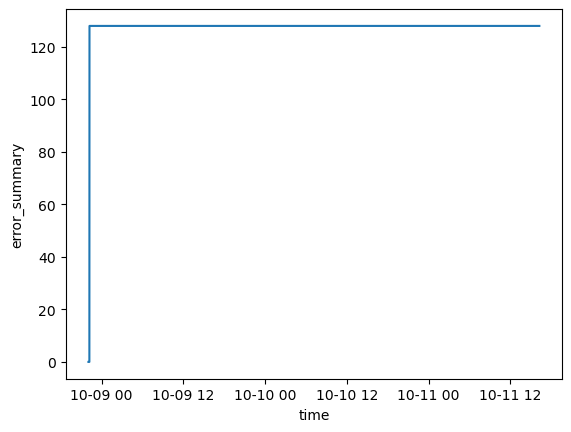

In [6]:
plt.plot(hk_ts['time'].to_datetime(), hk_ts['error_summary'])
plt.ylabel('error_summary')
plt.xlabel('time')

In [7]:
print('MeDDEA was turned on at: ', hk_ts['time'][0])
print('The rogue_pps error flag was activated at: ', hk_ts['time'][np.where(hk_ts['error_summary'] == 128)][0])
print('MeDDEA was turned off at: ', hk_ts['time'][-1])

MeDDEA was turned on at:  2025-10-08 22:03:24.000
The rogue_pps error flag was activated at:  2025-10-08 22:11:44.000
MeDDEA was turned off at:  2025-10-11 16:14:34.000


The rogue pps error flag was activated 8 minutes and 20 seconds after MeDDEA was turned on. 

Text(0.5, 0, 'time')

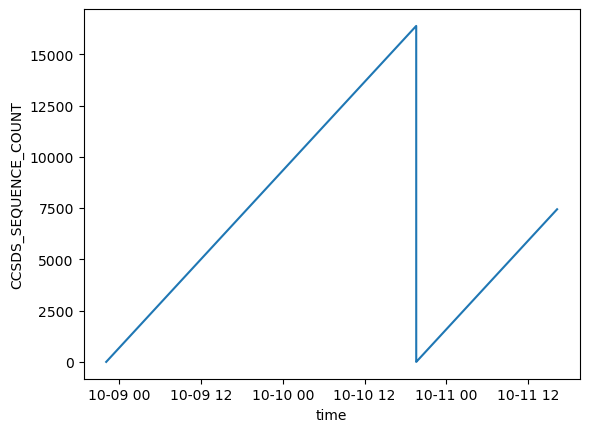

In [8]:
plt.plot(hk_ts['time'].to_datetime(), hk_ts['CCSDS_SEQUENCE_COUNT'])
plt.ylabel('CCSDS_SEQUENCE_COUNT')
plt.xlabel('time')

Text(0.5, 1.0, 'Corrected CCSDS_SEQUENCE_COUNT')

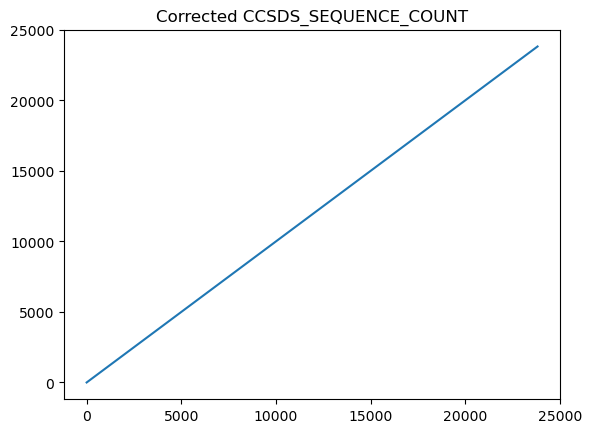

In [9]:
def corrected_seq_count(sequence_count, rollover_value=2**14):
    sequence_count = np.array(sequence_count, dtype=int)
    unwrapped = sequence_count.copy()
    
    offset = 0
    for i in range(1, len(sequence_count)):
        if sequence_count[i] < sequence_count[i-1] - rollover_value/2:
            offset += rollover_value
        unwrapped[i] += offset
    
    return unwrapped

corrected_sequence = corrected_seq_count(hk_ts['CCSDS_SEQUENCE_COUNT'])

plt.plot(corrected_sequence)
plt.title('Corrected CCSDS_SEQUENCE_COUNT')

In [10]:
# If there are any sequence counts that are not incrementing correctly, identify where this occurs. 

diff_check = np.diff(corrected_sequence)
is_incrementing_correctly = np.all(diff_check == 1)

print(f"All differences are 1: {is_incrementing_correctly}")
print(f"Unique diff values: {np.unique(diff_check)}")

if not is_incrementing_correctly:
    problem_indices = np.where(diff_check != 1)[0]
    print(f"Problems at indices: {problem_indices}")
    print(f"Problem diff values: {diff_check[problem_indices]}")

All differences are 1: True
Unique diff values: [1]


Examine fp_temp. Why does fp_temp decrease suddenly? The X-panels had been deployed on 10/6/25, but the Y-panels had yet to be deployed. Chris M. confirmed that ES had repositioned the spacecraft at this time (17:30:41) on 10/9/25, which aligns well with the temperature drop observed. 

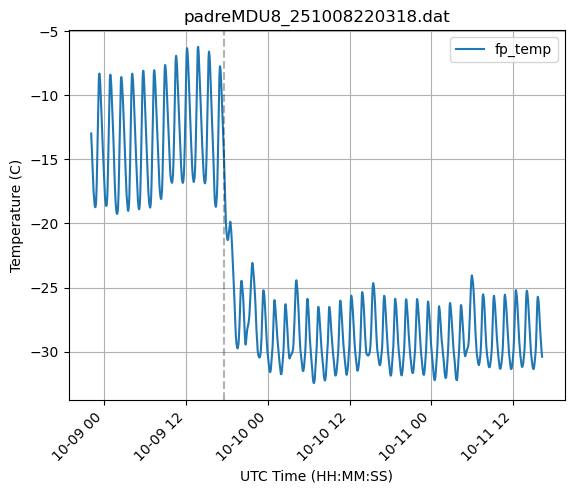

In [11]:
data=hk_ts['fp_temp']
f=calibration.get_calibration_func('fp_temp')
converted_data=f(data)
#print(np.shape(converted_data))
plt.plot(hk_ts.time.to_datetime(), converted_data, label='fp_temp')
plt.axvline(Time('2025-10-09T17:30:41').to_datetime(), color='black', linestyle='dashed', alpha=0.3)
plt.xticks(rotation=45, ha='right') 
plt.title(str(file))
plt.xlabel('UTC Time (HH:MM:SS)')
plt.ylabel('Temperature (C)')
plt.grid()
plt.legend()
plt.show()

Examine the other temperatures. 

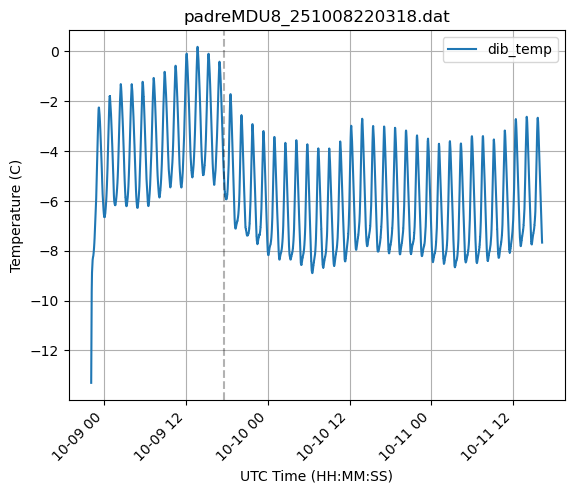

In [12]:
#plot_hk_converted(hk_ts, 'dib_temp', 'Temperature (C)', str(file), plot=True, hist=True)

data=hk_ts['dib_temp']
f=calibration.get_calibration_func('dib_temp')
converted_data=f(data)
#print(np.shape(converted_data))
plt.plot(hk_ts.time.to_datetime(), converted_data, label='dib_temp')
plt.axvline(Time('2025-10-09T17:30:41').to_datetime(), color='black', linestyle='dashed', alpha=0.3)
plt.xticks(rotation=45, ha='right') 
plt.title(str(file))
plt.xlabel('UTC Time (HH:MM:SS)')
plt.ylabel('Temperature (C)')
plt.grid()
plt.legend()
plt.show()

The dib_temp stayed fairly consistent throughout, in spite of ES repositioning the spacecraft. 

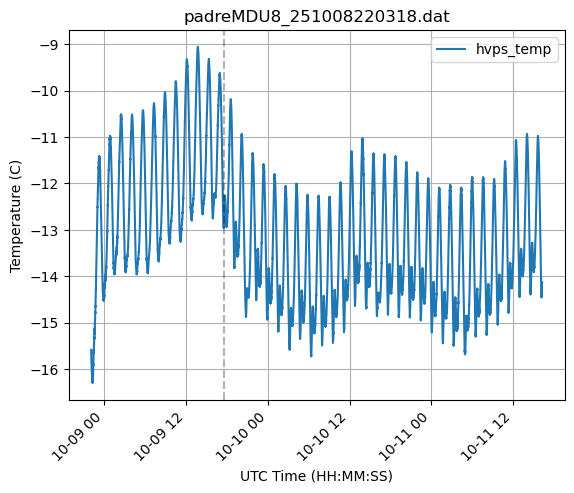

In [13]:
#plot_hk_converted(hk_ts, 'hvps_temp', 'Temperature (C)', str(file), plot=True, hist=True)

data=hk_ts['hvps_temp']
f=calibration.get_calibration_func('hvps_temp')
converted_data=f(data)
#print(np.shape(converted_data))
plt.plot(hk_ts.time.to_datetime(), converted_data, label='hvps_temp')
plt.axvline(Time('2025-10-09T17:30:41').to_datetime(), color='black', linestyle='dashed', alpha=0.3)
plt.xticks(rotation=45, ha='right') 
plt.title(str(file))
plt.xlabel('UTC Time (HH:MM:SS)')
plt.ylabel('Temperature (C)')
plt.grid()
plt.legend()
plt.show()